In [349]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [350]:
df = pd.read_csv('heart.csv')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [351]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [352]:
df.shape

(1025, 14)

In [353]:
X = df.drop('target', axis=1)
Y = df['target']

In [354]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, Y, random_state=42, test_size=0.2)

In [355]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
clf = DecisionTreeClassifier(max_depth=3)

In [356]:
clf.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=3)

In [357]:
pred = clf.predict(x_test)

In [358]:
from sklearn.metrics import classification_report, accuracy_score

print(accuracy_score(y_test, pred))

0.7804878048780488


In [359]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.85      0.68      0.75       102
           1       0.73      0.88      0.80       103

    accuracy                           0.78       205
   macro avg       0.79      0.78      0.78       205
weighted avg       0.79      0.78      0.78       205



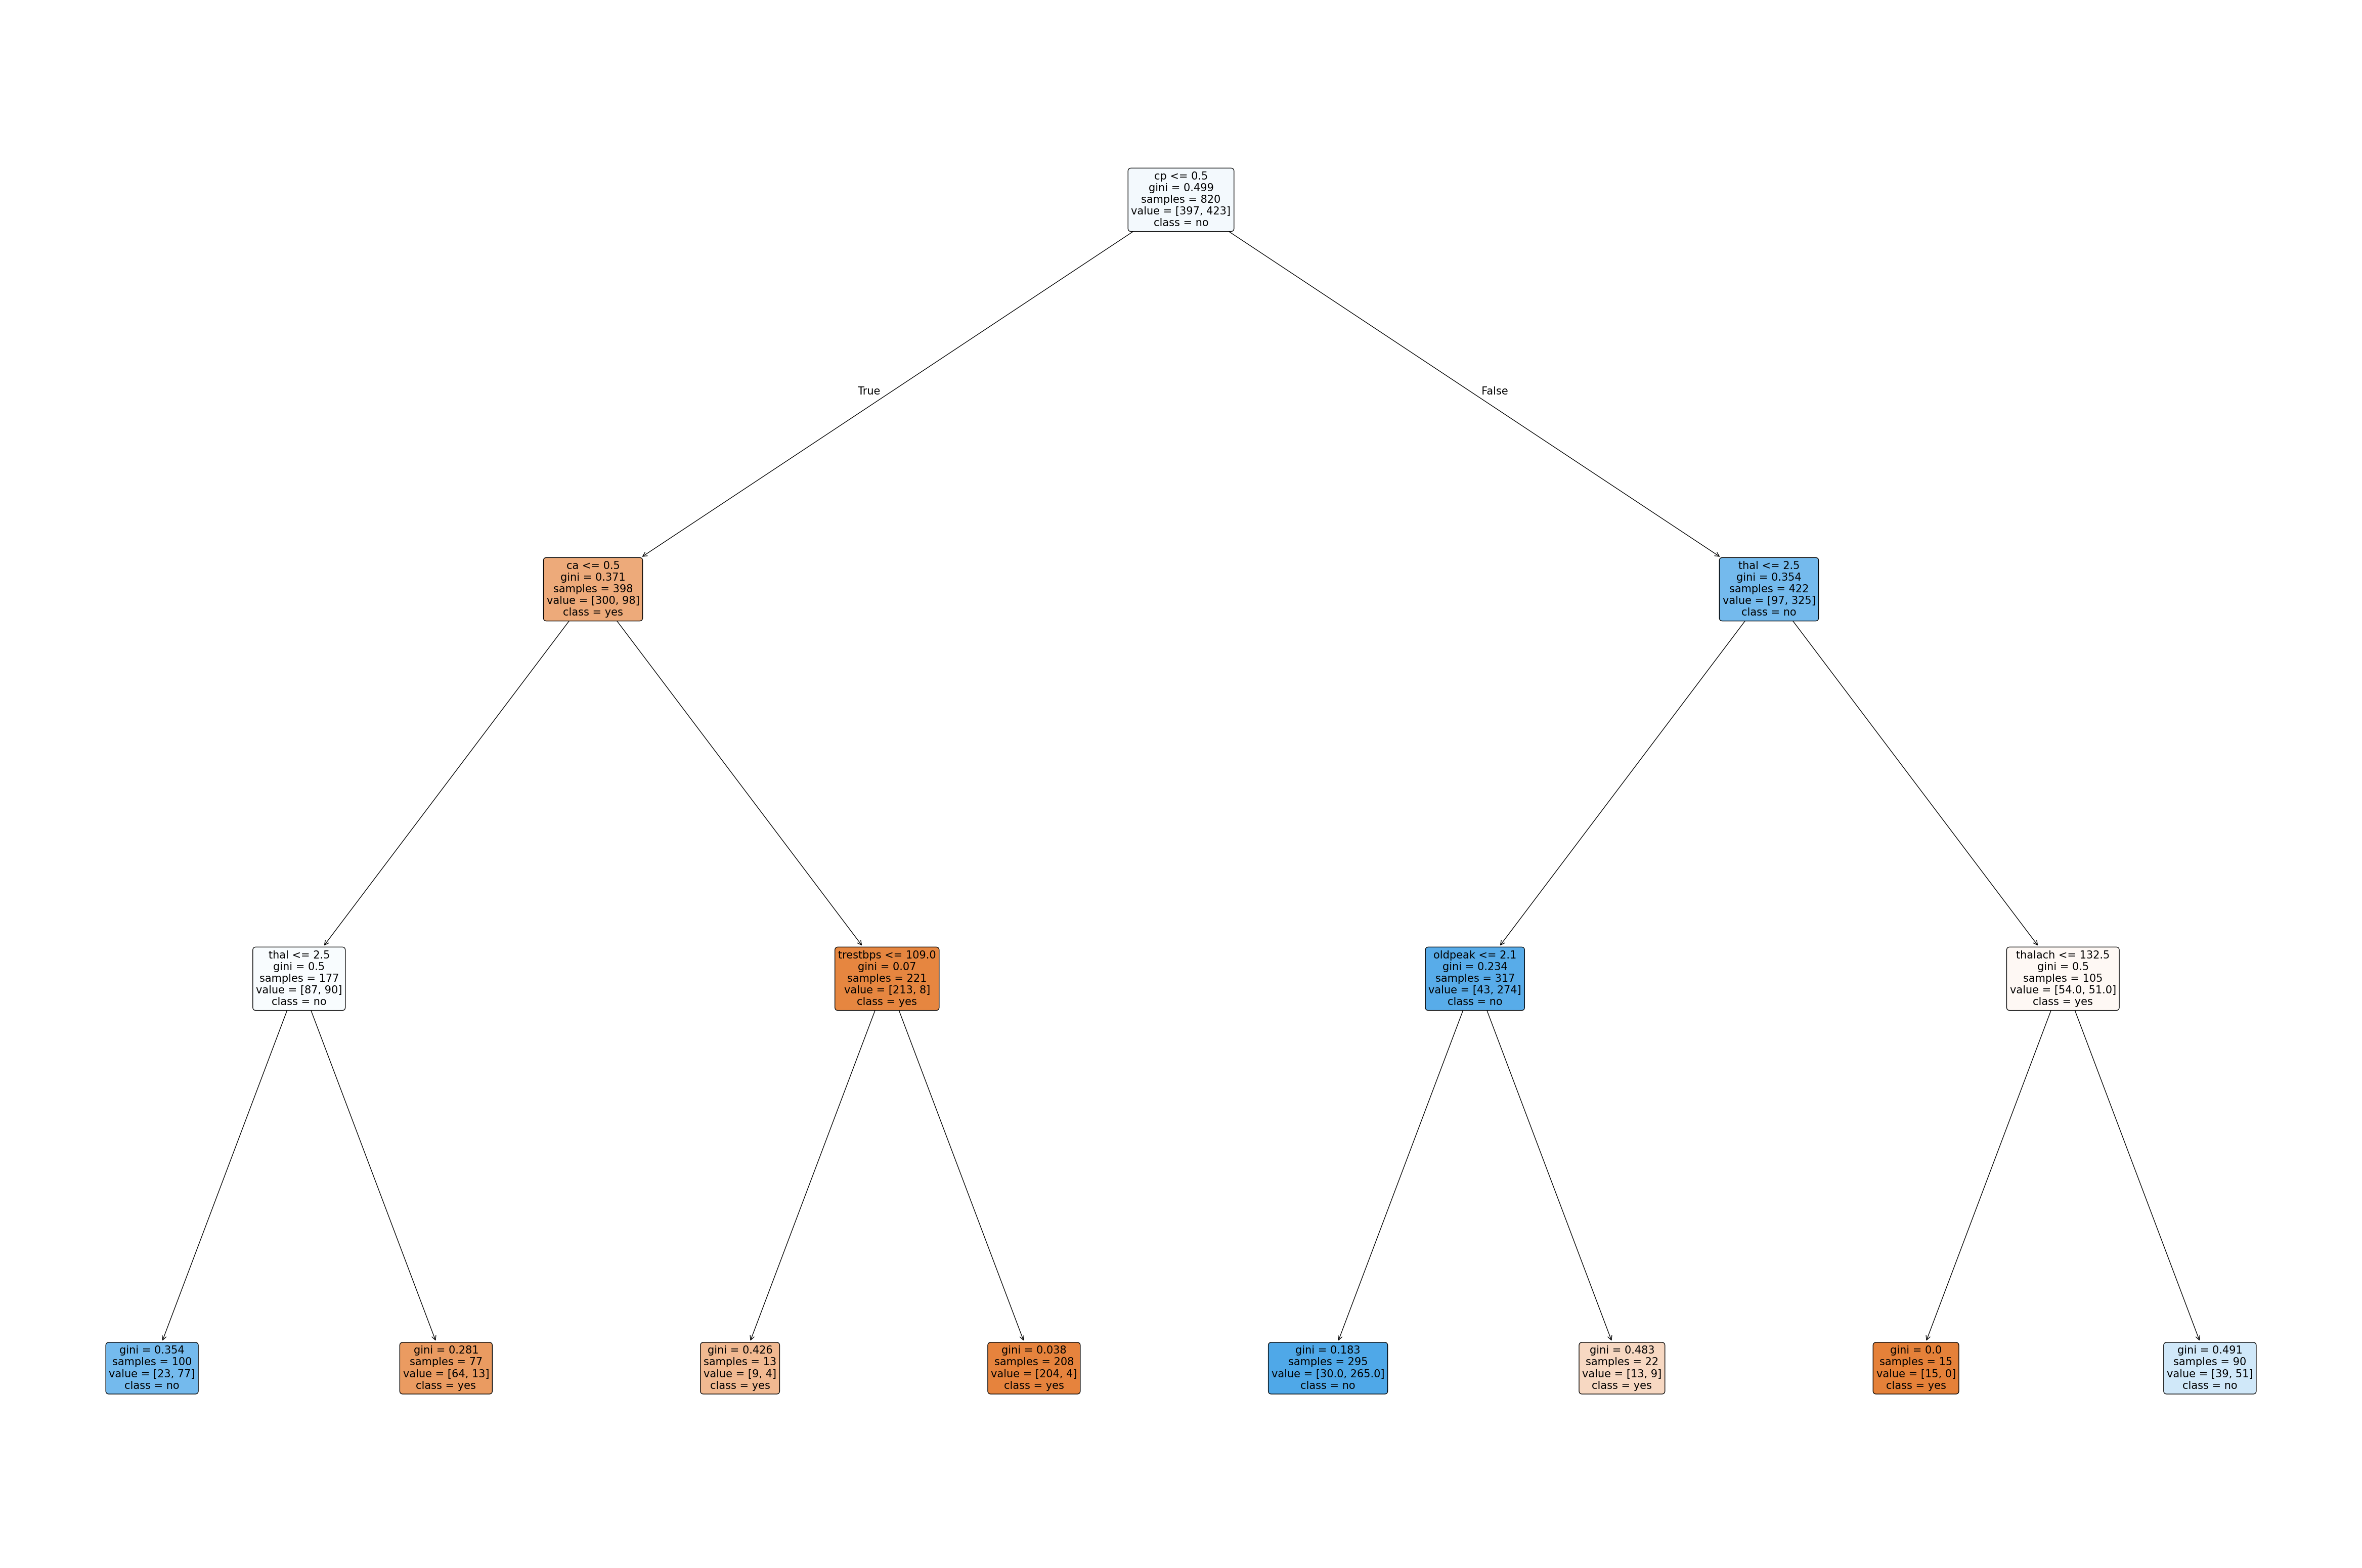

In [360]:
label = Y.map({0: 'yes', 1:'no'}).unique()

plt.figure(figsize=(60,40))
plot_tree(clf, feature_names= X.columns, class_names= label, rounded=True, filled=True, fontsize=15)
plt.show()

In [361]:
df1 = pd.read_csv('Salary_Data.csv')
df1

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0
6700,32.0,Male,High School,Sales Associate,3.0,50000.0
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0


In [362]:
df1 = df1.dropna()

In [363]:
categorical = ['Gender', 'Job Title', 'Education Level']
numerical = ['Age', 'Years of Experience']

In [364]:
df1['Education Level'].unique()

array(["Bachelor's", "Master's", 'PhD', "Bachelor's Degree",
       "Master's Degree", 'High School', 'phD'], dtype=object)

In [365]:
df1['Education Level'] = df1['Education Level'].map({"Bachelor's":1, "Master's":2, 'PhD':3, "Bachelor's Degree":1,
       "Master's Degree":2, 'High School':0, 'phD':3})

C:\Users\Asus\AppData\Local\Temp\ipykernel_26572\3499374275.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Education Level'] = df1['Education Level'].map({"Bachelor's":1, "Master's":2, 'PhD':3, "Bachelor's Degree":1,


In [366]:
X = df1.drop('Salary', axis=1)
Y = df1['Salary']

In [367]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, Y, random_state=42, test_size=0.2)

In [368]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor, plot_tree

preprocessor = ColumnTransformer([
    ('scaler', StandardScaler(), numerical),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical)
])

In [369]:
clf1 = Pipeline([
    ('preprocesssing', preprocessor),
    ('model', DecisionTreeRegressor())
])

In [370]:
clf1.fit(x_train, y_train)

Pipeline(steps=[('preprocesssing',
                 ColumnTransformer(transformers=[('scaler', StandardScaler(),
                                                  ['Age',
                                                   'Years of Experience']),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Gender', 'Job Title',
                                                   'Education Level'])])),
                ('model', DecisionTreeRegressor())])

In [371]:
pred = clf1.predict(x_test)

c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [372]:
from sklearn.metrics import r2_score, mean_absolute_percentage_error, mean_squared_error

print(r2_score(y_test, pred))
print(mean_absolute_percentage_error(y_test, pred))
print(mean_squared_error(y_test, pred))

0.9698976730502031
0.10390311261825337
85835558.58405805


In [373]:
clf1.score(x_test, y_test)

c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


0.9698976730502031